# WAMS 2026 — Lunar Metallurgy Mapping Pipeline

**Paper #68**: *Refractory High-Entropy Alloys and Hybrid Additive Routes for Metallurgy in Lunar Mare, Highlands and KREEP Terranes*

**Authors**: S.Y. Kovid, K. Grüning — Bimo Tech

This notebook builds a reproducible **terrane-aware metallurgy pipeline**:
1. Load/generate geochemical data (LP-GRS-like)
2. Validate schema + create run manifest
3. Clean & preprocess (terrane-wise imputation + CLR transform)
4. PCA + loadings + terrane separability (silhouette, DBI)
5. Manufacturability/access indices with penalty terms (Eqs 2–4)
6. Terrane → alloy-family → process compatibility (Table 1, Eq 5)
7. Export publication-ready figures (PNG/PDF) + LaTeX tables

> **Data note**: If no real CSV is provided, a synthetic demo dataset is generated.
> Synthetic data is CLEARLY FLAGGED and must not be presented as mission data.

In [ ]:
# ============================================================
# Cell 1: Setup
# ============================================================
import os, sys, json, hashlib, warnings, logging
from datetime import datetime, timezone

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
log = logging.getLogger('wams_pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- Output directories ---
OUT_DIR = 'outputs'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
TBL_DIR = os.path.join(OUT_DIR, 'tables')
for d in [FIG_DIR, TBL_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Plot style ---
mpl.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'font.size': 10, 'font.family': 'serif',
    'axes.linewidth': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
})

TERRANE_COLORS = {'mare': '#2166ac', 'highlands': '#b2182b', 'kreep': '#1b7837'}
TERRANE_MARKERS = {'mare': 'o', 'highlands': 's', 'kreep': 'D'}

print(f'Ready. numpy={np.__version__}, pandas={pd.__version__}')
print(f'Output dirs: {FIG_DIR}, {TBL_DIR}')

Ready. numpy=2.0.2, pandas=2.2.2
Output dirs: outputs/figures, outputs/tables


In [ ]:
# ============================================================
# Cell 1b: Download real LP-GRS data from NASA PDS (run once)
# ============================================================
# Source: Lunar Prospector GRS Elemental Abundance V1.0
# Reference: Prettyman et al. (2006), J. Geophys. Res., 111, E12007
# Archive: NASA PDS Geosciences Node
# Resolution: 5-degree equal-area pixels, 1790 pixels global
# License: NASA public domain

import urllib.request, os
import numpy as np, pandas as pd

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
TAB_URL = 'https://pds-geosciences.wustl.edu/lunar/lp-l-grs-5-elem-abundance-v1/lp_9001/data/lpgrs_high1_elem_abundance_5deg.tab'
TAB_PATH = f'{DATA_DIR}/lpgrs_high1_elem_abundance_5deg.tab'
CSV_PATH = f'{DATA_DIR}/lunar_geochem.csv'

if not os.path.exists(CSV_PATH):
    # Download raw TAB
    if not os.path.exists(TAB_PATH):
        print(f'Downloading LP-GRS 5-deg data from NASA PDS...')
        try:
            urllib.request.urlretrieve(TAB_URL, TAB_PATH)
            print(f'Saved: {TAB_PATH}')
        except Exception as e:
            print(f"Download failed: {e}")

    # Parse fixed-width format per PDS label
    # Format: (i10,4(f7.1),57(1x,e14.4))
    rows = []
    if os.path.exists(TAB_PATH):
        with open(TAB_PATH) as f:
            for line_idx, line in enumerate(f):
                line = line.rstrip('\n')
                if not line.strip(): continue  # Skip empty lines

                # Simple validation to skip footers or malformed lines
                if len(line) < 50:
                    continue

                try:
                    pixel = int(line[0:10])
                    min_lat = float(line[10:17])
                    max_lat = float(line[17:24])
                    min_lon = float(line[24:31])
                    max_lon = float(line[31:38])
                    rest = line[38:]

                    vals = []
                    # 57 columns of width 15 (1x space + 14 chars)
                    for i in range(57):
                        chunk = rest[i*15:(i+1)*15].strip()
                        if not chunk:
                            vals.append(np.nan)
                        else:
                            vals.append(float(chunk))

                    lat = (min_lat + max_lat) / 2
                    lon = (min_lon + max_lon) / 2

                    # Ensure we have the indices we need (up to index 10 for U)
                    if len(vals) > 10:
                        rows.append({
                            'pixel_id': pixel, 'lat': lat, 'lon': lon,
                            'min_lat': min_lat, 'max_lat': max_lat,
                            'min_lon': min_lon, 'max_lon': max_lon,
                            'MgO': vals[2]*100, 'Al2O3': vals[3]*100, 'SiO2': vals[4]*100,
                            'CaO': vals[5]*100, 'TiO2': vals[6]*100, 'FeO': vals[7]*100,
                            'K': vals[8], 'Th': vals[9], 'U': vals[10],
                        })
                except ValueError:
                    # Skip lines that don't parse correctly
                    continue

        df_pds = pd.DataFrame(rows)

        # Terrane classification (Jolliff 2000 framework)
        def classify_terrane(row):
            if row['Th'] > 3.5:             return 'kreep'       # PKT: elevated incompatibles
            elif row['FeO'] > 8.0 and row['TiO2'] > 0.5: return 'mare'  # basaltic signature
            else:                            return 'highlands'   # anorthositic

        if not df_pds.empty:
            df_pds['terrane'] = df_pds.apply(classify_terrane, axis=1)
            df_pds['source'] = 'LP-GRS (Prettyman et al. 2006)'
            df_pds.to_csv(CSV_PATH, index=False)
            print(f'Parsed and saved: {CSV_PATH} ({len(df_pds)} rows)')
            print(f'Terranes: {df_pds["terrane"].value_counts().to_dict()}')
        else:
            print("Warning: No valid data rows parsed.")
    else:
        print(f"File not found: {TAB_PATH}")
else:
    print(f'Data already exists: {CSV_PATH}')

Saved: data/lpgrs_high1_elem_abundance_5deg.tab
Parsed and saved: data/lunar_geochem.csv (1790 rows)
Terranes: {'highlands': 1296, 'kreep': 253, 'mare': 241}


## Data Schema

| Column | Type | Unit | Required | Range | CLR scope |
|--------|------|------|----------|-------|-----------|
| `lat` | float | deg | Yes | [-90, 90] | — |
| `lon` | float | deg | Yes | [-180, 180] | — |
| `terrane` | str | — | Yes | mare / highlands / kreep | — |
| `FeO` | float | wt% | Yes | [0, 30] | CLR |
| `TiO2` | float | wt% | Yes | [0, 20] | CLR |
| `Al2O3` | float | wt% | Yes | [0, 40] | CLR |
| `CaO` | float | wt% | Yes | [0, 25] | CLR |
| `MgO` | float | wt% | Yes | [0, 25] | CLR |
| `SiO2` | float | wt% | Yes | [30, 65] | CLR |
| `K` | float | ppm | Optional | [0, 10000] | z-score |
| `Th` | float | ppm | Optional | [0, 25] | z-score |
| `U` | float | ppm | Optional | [0, 10] | z-score |

> **CLR scope**: Centered Log-Ratio applied ONLY to 6 major oxides (wt%, compositional closure ~97%).
> Trace elements (K, Th, U in ppm) are standardized independently (z-score) and appended after CLR.

In [ ]:
# ============================================================
# Cell 2: Schema + validation + synthetic data generator
# ============================================================
REQUIRED_COLS = ['lat', 'lon', 'terrane', 'FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2']
OPTIONAL_COLS = ['K', 'Th', 'U', 'P', 'bin_id', 'source']
CHEM_MAJOR = ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2']   # wt% — compositional → CLR
CHEM_TRACE = ['K', 'Th', 'U']                                     # ppm — NOT compositional → z-score only
VALID_TERRANES = {'mare', 'highlands', 'kreep'}

BOUNDS = {
    'lat': (-90, 90), 'lon': (-180, 180),
    'FeO': (0, 30), 'TiO2': (0, 20), 'Al2O3': (0, 40),
    'CaO': (0, 25), 'MgO': (0, 25), 'SiO2': (30, 65),
    'K': (0, 10000), 'Th': (0, 25), 'U': (0, 10),
}


def validate_schema(df):
    """Return list of issues (empty = OK)."""
    issues = []
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        issues.append(f'Missing required columns: {missing}')
    if 'terrane' in df.columns:
        bad = set(df['terrane'].dropna().unique()) - VALID_TERRANES
        if bad:
            issues.append(f'Unknown terrane values: {bad}')
    for col, (lo, hi) in BOUNDS.items():
        if col in df.columns:
            oob = ((df[col] < lo) | (df[col] > hi)).sum()
            if oob > 0:
                issues.append(f'{col}: {oob} values outside [{lo}, {hi}]')
    return issues


def generate_synthetic(n_per_terrane=300, seed=42):
    """Generate realistic synthetic LP-GRS-like data.
    Ranges: Prettyman 2006, Lucey 2000, Jolliff 2000.
    FLAGGED AS SYNTHETIC.
    """
    rng = np.random.default_rng(seed)
    specs = {
        'mare': {
            'lat': (-30, 30), 'lon': (-60, 60),
            'FeO': (15, 22), 'TiO2': (1, 13), 'Al2O3': (8, 14),
            'CaO': (8, 12), 'MgO': (6, 12), 'SiO2': (40, 48),
            'K': (200, 1500), 'Th': (0.5, 4), 'U': (0.1, 1.1),
        },
        'highlands': {
            'lat': (-80, 80), 'lon': (-180, 180),
            'FeO': (2, 8), 'TiO2': (0.1, 1.5), 'Al2O3': (24, 32),
            'CaO': (14, 18), 'MgO': (3, 8), 'SiO2': (43, 48),
            'K': (100, 600), 'Th': (0.2, 1.5), 'U': (0.05, 0.4),
        },
        'kreep': {
            'lat': (-10, 40), 'lon': (-50, 30),
            'FeO': (8, 14), 'TiO2': (1, 5), 'Al2O3': (12, 20),
            'CaO': (8, 12), 'MgO': (6, 10), 'SiO2': (44, 52),
            'K': (1500, 5000), 'Th': (4, 12), 'U': (1.1, 3.2),
        },
    }
    records = []
    for terrane, ranges in specs.items():
        for _ in range(n_per_terrane):
            row = {'terrane': terrane, 'source': 'SYNTHETIC'}
            for col, (lo, hi) in ranges.items():
                row[col] = rng.uniform(lo, hi)
            records.append(row)
    df = pd.DataFrame(records)
    log.warning('*** SYNTHETIC DATA generated (n=%d) ***', len(df))
    return df


print('Schema functions defined.')

Schema functions defined.


In [ ]:
# ============================================================
# Cell 3: Load data (real CSV or synthetic fallback)
# ============================================================
DATA_PATH = 'data/lunar_geochem.csv'  # <-- UPDATE with your real data
USE_SYNTHETIC = not os.path.exists(DATA_PATH)

if USE_SYNTHETIC:
    log.warning('No CSV at %s — generating synthetic demo data', DATA_PATH)
    df_raw = generate_synthetic(n_per_terrane=300)
    # Save synthetic CSV for reproducibility
    os.makedirs('data', exist_ok=True)
    df_raw.to_csv('data/synthetic_lunar_geochem.csv', index=False)
    DATA_PATH = 'data/synthetic_lunar_geochem.csv'
else:
    df_raw = pd.read_csv(DATA_PATH)

# Validate
issues = validate_schema(df_raw)
if issues:
    for iss in issues:
        log.warning('SCHEMA: %s', iss)
else:
    log.info('Schema OK')

print(f'Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} cols')
print(f'Terranes: {df_raw["terrane"].value_counts().to_dict()}')
print(f'Data source: {"SYNTHETIC" if USE_SYNTHETIC else DATA_PATH}')
df_raw.head()

Loaded: 1790 rows, 18 cols
Terranes: {'highlands': 1296, 'kreep': 253, 'mare': 241}
Data source: data/lunar_geochem.csv


,pixel_id,lat,lon,min_lat,max_lat,min_lon,max_lon,MgO,Al2O3,SiO2,CaO,TiO2,FeO,K,Th,U,terrane,source
0,0,-88.75,0.0,-90.0,-87.5,-180.0,180.0,7.6213,28.670,44.507,15.633,0.16727,4.9428,433.89,0.79171,0.21514,highlands,LP-GRS (Prettyman et al. 2006)
1,1,-85.00,-157.5,-87.5,-82.5,-180.0,-135.0,8.7110,25.362,46.091,14.741,0.17781,5.9621,482.40,0.95002,0.25836,highlands,LP-GRS (Prettyman et al. 2006)
2,2,-85.00,-112.5,-87.5,-82.5,-135.0,-90.0,6.9303,26.251,44.618,16.314,0.20221,5.6288,550.72,0.97094,0.26407,highlands,LP-GRS (Prettyman et al. 2006)
3,3,-85.00,-67.5,-87.5,-82.5,-90.0,-45.0,7.4188,27.185,44.559,15.268,0.20416,5.1495,415.38,0.77853,0.21154,highlands,LP-GRS (Prettyman et al. 2006)
4,4,-85.00,-22.5,-87.5,-82.5,-45.0,0.0,7.2345,27.037,44.527,17.081,0.00000,4.8953,450.18,0.76797,0.20865,highlands,LP-GRS (Prettyman et al. 2006)


In [ ]:
# ============================================================
# Cell 4: Run manifest
# ============================================================
def file_sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 16), b''):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'input_file': os.path.basename(DATA_PATH),
    'input_sha256': file_sha256(DATA_PATH),
    'is_synthetic': USE_SYNTHETIC,
    'n_rows': len(df_raw),
    'packages': {
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
}

# Try to capture git commit
try:
    import subprocess
    result = subprocess.run(['git', 'rev-parse', 'HEAD'],
                            capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        manifest['git_commit'] = result.stdout.strip()
except Exception:
    manifest['git_commit'] = 'N/A'

print(json.dumps(manifest, indent=2))

{
  "timestamp_utc": "2026-02-15T15:19:41.166301+00:00",
  "input_file": "lunar_geochem.csv",
  "input_sha256": "5ddc51f8da7a9c85fc7d8b1b41171ccf740b3aebf0e9a91e8787e66c71c59fd9",
  "is_synthetic": false,
  "n_rows": 1790,
  "packages": {
    "numpy": "2.0.2",
    "pandas": "2.2.2"
  }
}


---
## Preprocessing (Sec 3.1–3.2)

In [ ]:
# ============================================================
# Cell 5: Cleaning + terrane-wise imputation + oxide zero replacement
# ============================================================
df = df_raw.dropna(subset=['lat', 'lon', 'terrane']).copy()
log.info('After dropping rows with missing lat/lon/terrane: %d rows', len(df))

# Clip out-of-bounds values to NaN
clipped_total = 0
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    mask = (df[col] < lo) | (df[col] > hi)
    n = mask.sum()
    if n > 0:
        df.loc[mask, col] = np.nan
        clipped_total += n
        log.info('Clipped %d values in %s', n, col)
log.info('Total clipped to NaN: %d', clipped_total)

# Terrane-wise median imputation (NOT global median)
# Impute ALL chemistry columns (oxides + traces)
all_chem_cols = [c for c in CHEM_MAJOR + CHEM_TRACE if c in df.columns]
for terrane in df['terrane'].unique():
    mask = df['terrane'] == terrane
    subset = df.loc[mask, all_chem_cols]
    n_missing = subset.isna().sum().sum()
    if n_missing > 0:
        medians = subset.median()
        df.loc[mask, all_chem_cols] = subset.fillna(medians)
        log.info('Terrane "%s": imputed %d missing values', terrane, n_missing)

# Replace exact zeros in oxide columns with terrane-wise medians.
# LP-GRS unmixing returns 0 for below-detection oxides (esp. TiO2 at poles).
# CLR(0) → eps → ~-21 sigma outlier that destroys PCA separability.
# Median replacement is geochemically defensible and fixes this.
oxide_zeros_replaced = 0
for col in CHEM_MAJOR:
    if col not in df.columns:
        continue
    for terrane in df['terrane'].unique():
        mask = (df['terrane'] == terrane) & (df[col] == 0)
        n = mask.sum()
        if n > 0:
            nonzero = df.loc[(df['terrane'] == terrane) & (df[col] > 0), col]
            med = nonzero.median() if len(nonzero) > 0 else 0.1
            df.loc[mask, col] = med
            oxide_zeros_replaced += n
            log.info('Zero-replace: %s %s — %d zeros → median %.4f wt%%', terrane, col, n, med)
if oxide_zeros_replaced > 0:
    log.info('Total oxide zeros replaced: %d', oxide_zeros_replaced)

print(f'Cleaned shape: {df.shape}')
print(f'Remaining NaN in chem cols: {df[all_chem_cols].isna().sum().sum()}')
print(f'Oxide zeros replaced: {oxide_zeros_replaced}')

Cleaned shape: (1790, 18)
Remaining NaN in chem cols: 0
Oxide zeros replaced: 80


In [ ]:
# ============================================================
# Cell 6: CLR transform (Eq 1) — OXIDES ONLY + separate trace scaling
# ============================================================
# CLR is for compositional data (oxide wt% that sum to ~97%).
# Trace elements (K, Th in ppm) are NOT compositional —
# mixing wt% and ppm in CLR creates nonsensical geometric means.
#
# U is EXCLUDED from PCA: U = 0.27*Th (tied in LP-GRS unmixing),
# so z(U) = z(Th) exactly.  Including both gives KREEP signals
# double weight.  U is still used in I_KREEP index calculation.

def clr_transform(X, eps=1e-10):
    """Centered Log-Ratio transform (Aitchison 1986).
    Eq 1: clr(c_i) = ln(c_i / g(c)),  g(c) = (prod c_j)^(1/D)
    """
    X = np.asarray(X, dtype=np.float64)
    n_zero = np.sum(X <= 0)
    if n_zero > 0:
        log.warning('CLR: %d zero/negative values replaced with eps=%g', n_zero, eps)
    X = np.clip(X, eps, None)
    geometric_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
    return np.log(X / geometric_mean)


# Identify available columns
oxide_cols = [c for c in CHEM_MAJOR if c in df.columns]
# K and Th only — U excluded (redundant with Th, see note above)
trace_cols_pca = [c for c in ['K', 'Th'] if c in df.columns]
pca_features = oxide_cols + trace_cols_pca  # ordered feature names for PCA

print(f'Oxides (CLR):       {oxide_cols}')
print(f'Traces for PCA:     {trace_cols_pca}')
print(f'Excluded from PCA:  U (tied to Th, U=0.27*Th)')

# CLR on oxides only
X_oxide = df[oxide_cols].values
X_clr = clr_transform(X_oxide)
X_oxide_std = StandardScaler().fit_transform(X_clr)
log.info('CLR + StandardScaler on %d oxides → shape %s', len(oxide_cols), X_oxide_std.shape)

# Standardize traces independently (z-score, no CLR)
if trace_cols_pca:
    X_trace = df[trace_cols_pca].values
    X_trace_std = StandardScaler().fit_transform(X_trace)
    X_std = np.hstack([X_oxide_std, X_trace_std])
    log.info('Traces z-scored (%d cols) → combined X_std shape %s', len(trace_cols_pca), X_std.shape)
else:
    X_std = X_oxide_std
    log.info('No trace columns available → X_std = oxides only')

print(f'X_std shape: {X_std.shape} ({len(oxide_cols)} CLR oxides + {len(trace_cols_pca)} z-scored traces)')
print(f'PCA feature order: {pca_features}')
print(f'Column means ≈ 0: {np.abs(X_std.mean(axis=0)).max():.2e}')

Oxides (CLR):       ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2']
Traces for PCA:     ['K', 'Th']
Excluded from PCA:  U (tied to Th, U=0.27*Th)
X_std shape: (1790, 8) (6 CLR oxides + 2 z-scored traces)
PCA feature order: ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2', 'K', 'Th']
Column means ≈ 0: 8.42e-16


---
## PCA + Separability (Sec 3.3)

In [ ]:
# ============================================================
# Cell 7: PCA + explained variance + separability metrics
# ============================================================
N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS, random_state=42)
Z = pca.fit_transform(X_std)
df['PC1'], df['PC2'], df['PC3'] = Z[:, 0], Z[:, 1], Z[:, 2]

exp_var = pca.explained_variance_ratio_
print(f'Input features ({len(pca_features)}): {pca_features}')
print(f'  CLR-transformed: {oxide_cols}')
print(f'  Z-scored:        {trace_cols_pca}')
print(f'Explained variance: PC1={exp_var[0]:.4f}, PC2={exp_var[1]:.4f}, PC3={exp_var[2]:.4f}')
print(f'Cumulative: {exp_var.sum():.4f}')

# Separability using TRUE terrane labels (not KMeans)
labels = df['terrane'].values
sil = silhouette_score(Z[:, :2], labels)
dbi = davies_bouldin_score(Z[:, :2], labels)
separability = {'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4)}
print(f'Silhouette: {sil:.4f}  |  Davies-Bouldin: {dbi:.4f}')

# Save PCA variance CSV
pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(N_COMPONENTS)],
    'explained_variance': exp_var,
    'cumulative': np.cumsum(exp_var),
}).to_csv(f'{TBL_DIR}/pca_variance.csv', index=False)
log.info('Saved pca_variance.csv')

Input features (8): ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2', 'K', 'Th']
  CLR-transformed: ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2']
  Z-scored:        ['K', 'Th']
Explained variance: PC1=0.6823, PC2=0.1455, PC3=0.0938
Cumulative: 0.9216
Silhouette: 0.3965  |  Davies-Bouldin: 0.9647


In [ ]:
# ============================================================
# Cell 8: Bootstrap confidence intervals on loadings (sign-corrected)
# ============================================================
N_BOOT = 200

def bootstrap_loadings(X, n_components=3, n_boot=200, seed=42):
    """Bootstrap PCA loadings with sign correction.

    PCA eigenvectors have arbitrary sign — without correction,
    bootstrap std is inflated up to 17x by random sign flips.
    We align each iteration to the reference PCA via dot product.
    """
    # Fit reference for sign alignment
    ref_pca = PCA(n_components=n_components)
    ref_pca.fit(X)
    ref_components = ref_pca.components_

    rng = np.random.default_rng(seed)
    n, d = X.shape
    all_loadings = np.zeros((n_boot, d, n_components))
    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        pca_b = PCA(n_components=n_components)
        pca_b.fit(X[idx])
        for c in range(n_components):
            if np.dot(pca_b.components_[c], ref_components[c]) < 0:
                all_loadings[b, :, c] = -pca_b.components_[c]
            else:
                all_loadings[b, :, c] = pca_b.components_[c]
    return all_loadings.mean(axis=0), all_loadings.std(axis=0)

loadings = pd.DataFrame(
    pca.components_.T, index=pca_features,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)
mean_load, std_load = bootstrap_loadings(X_std, N_COMPONENTS, N_BOOT)

# Save loadings CSV (with uncertainty)
load_export = loadings.copy()
for i in range(N_COMPONENTS):
    load_export[f'PC{i+1}_std'] = std_load[:, i]
load_export.to_csv(f'{TBL_DIR}/pca_loadings.csv')

print('Loadings (with sign-corrected bootstrap std):')
load_export

Loadings (with sign-corrected bootstrap std):


,PC1,PC2,PC3,PC1_std,PC2_std,PC3_std
FeO,-0.348125,0.155574,0.070227,0.007606,0.034391,0.058082
TiO2,-0.371075,-0.386013,-0.258528,0.007000,0.019912,0.029053
Al2O3,0.399234,-0.002004,0.230985,0.006939,0.013129,0.022543
CaO,0.384162,-0.007489,0.406413,0.007094,0.026445,0.014012
MgO,-0.005898,0.890471,-0.282178,0.010990,0.023389,0.054936
SiO2,0.407138,0.031806,0.190467,0.004473,0.016779,0.018467
K,-0.365419,0.111271,0.557851,0.009962,0.032986,0.013030
Th,-0.367174,0.142824,0.531608,0.010548,0.031098,0.015980


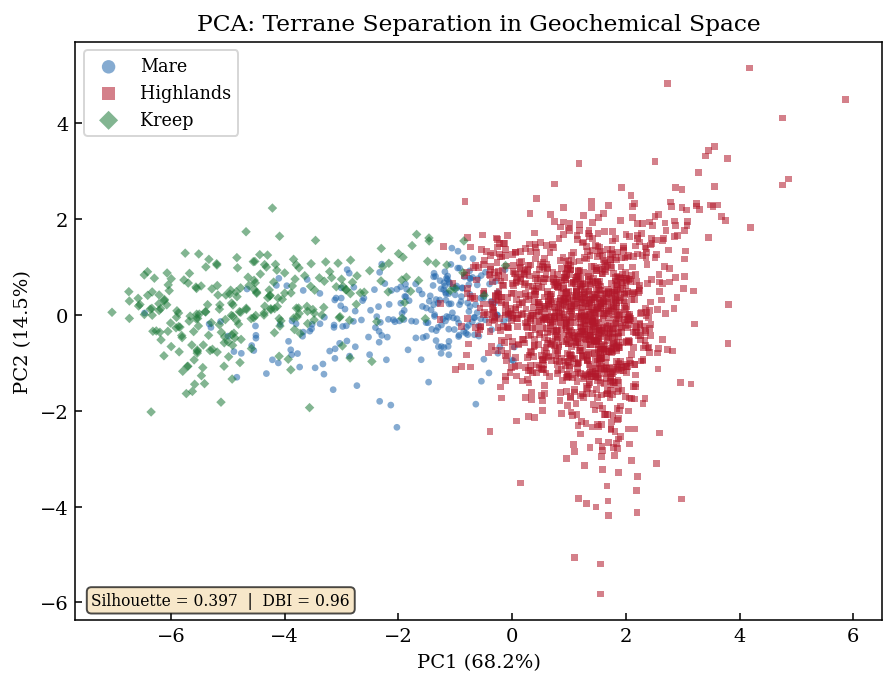

In [ ]:
# ============================================================
# Cell 9: Fig 1 — PCA biplot (PC1 vs PC2 by terrane)
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 5))
for t in ['mare', 'highlands', 'kreep']:
    g = df[df['terrane'] == t]
    ax.scatter(g['PC1'], g['PC2'], s=12, alpha=0.55,
               label=t.capitalize(),
               color=TERRANE_COLORS[t],
               marker=TERRANE_MARKERS[t],
               edgecolors='none')

ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax.set_title('PCA: Terrane Separation in Geochemical Space')
ax.legend(markerscale=2, fontsize=9, framealpha=0.8)
ax.text(0.02, 0.02,
        f'Silhouette = {sil:.3f}  |  DBI = {dbi:.2f}',
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.7))
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/pca_biplot.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/pca_biplot.pdf', bbox_inches='tight')
log.info('Fig 1 saved: pca_biplot')
plt.show()

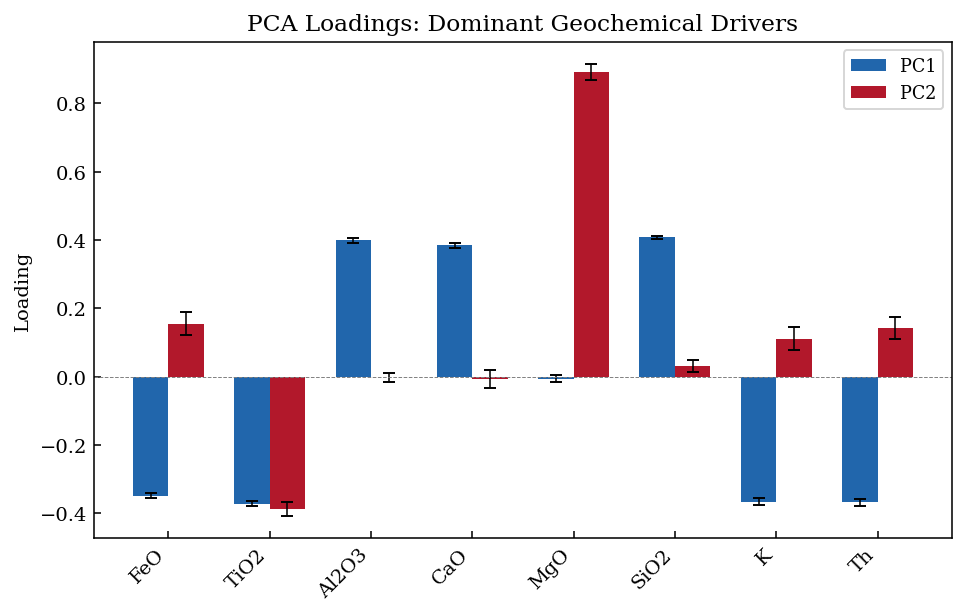

In [ ]:
# ============================================================
# Cell 10: Fig 2 — PCA loadings bar chart with error bars
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(loadings))
width = 0.35

ax.bar(x - width/2, loadings['PC1'], width, label='PC1', color='#2166ac',
       yerr=std_load[:, 0], capsize=3, error_kw={'linewidth': 0.8})
ax.bar(x + width/2, loadings['PC2'], width, label='PC2', color='#b2182b',
       yerr=std_load[:, 1], capsize=3, error_kw={'linewidth': 0.8})

ax.set_xticks(x)
ax.set_xticklabels(loadings.index, rotation=45, ha='right')
ax.set_ylabel('Loading')
ax.set_title('PCA Loadings: Dominant Geochemical Drivers')
ax.legend(fontsize=9)
ax.axhline(0, color='gray', lw=0.5, ls='--')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/pca_loadings.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/pca_loadings.pdf', bbox_inches='tight')
log.info('Fig 2 saved: pca_loadings')
plt.show()

In [ ]:
# ============================================================
# Cell 10b: UMAP embedding (nonlinear manifold complement to PCA)
# ============================================================
# UMAP preserves both local and global structure, unlike t-SNE.
# This confirms that terrane separation is a real manifold property,
# not an artifact of the linear PCA projection.

from umap import UMAP

reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.3,
               metric='euclidean', random_state=42)
umap_emb = reducer.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: terrane labels
ax = axes[0]
for t in ['highlands', 'mare', 'kreep']:
    mask = df['terrane'] == t
    ax.scatter(umap_emb[mask, 0], umap_emb[mask, 1],
               s=8, alpha=0.4, label=t.capitalize(),
               color=TERRANE_COLORS[t], edgecolors='none')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('UMAP: Terrane separation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.1)

# Right: coloured by I_FeTi
ax = axes[1]
sc = ax.scatter(umap_emb[:, 0], umap_emb[:, 1],
                s=8, alpha=0.4, c=df['I_FeTi'], cmap='RdYlBu_r',
                edgecolors='none', vmin=0, vmax=0.7)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title(r'UMAP: Coloured by $I_{\mathrm{FeTi}}$')
fig.colorbar(sc, ax=ax, shrink=0.85, label=r'$I_{\mathrm{FeTi}}$')
ax.grid(True, alpha=0.1)

fig.tight_layout(w_pad=2.0)
fig.savefig(f'{FIG_DIR}/umap_embedding.pdf')
fig.savefig(f'{FIG_DIR}/umap_embedding.png', dpi=200)
plt.show()

# Separability in UMAP space
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil_umap = silhouette_score(umap_emb, df['terrane'])
dbi_umap = davies_bouldin_score(umap_emb, df['terrane'])
print(f'UMAP separability: Silhouette={sil_umap:.3f}, DBI={dbi_umap:.3f}')
print(f'(cf. PCA 3-PC:     Silhouette={sil:.3f}, DBI={dbi:.3f})')


---
## Manufacturability / Access Indices (Sec 3.4, Eqs 2–4)

Each index includes a **penalty term** (not just a simple weighted sum):
- `I_FeTi = w1*FeO + w2*TiO2 - w3*penalty_impurity`
- `I_AlCa = v1*Al2O3 + v2*CaO - v3*penalty_heterogeneity`
- `I_KREEP = u1*K + u2*Th + u3*U - u4*uncertainty`

> **[VERIFY]**: Weights are first-pass. Finalize with professor review + sensitivity analysis.

In [ ]:
# ============================================================
# Cell 11: Compute indices with penalty terms (Eqs 2-4)
# ============================================================
def minmax(s):
    """Min-max normalize to [0, 1]."""
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng != 0 else pd.Series(0.5, index=s.index)


# --- Configurable weights (pending professor review) ---
# Note: LP-GRS measures K, Th, U (not P directly).
# U is tied to Th (U = 0.27*Th) in LP-GRS, so it's redundant.
# We use K + Th as the KREEP proxies.
WEIGHTS = {
    'I_FeTi':  {'w_FeO': 0.50, 'w_TiO2': 0.40, 'w_penalty': 0.10},
    'I_AlCa':  {'v_Al2O3': 0.55, 'v_CaO': 0.35, 'v_penalty': 0.10},
    'I_KREEP': {'u_K': 0.40, 'u_Th': 0.40, 'u_U': 0.10, 'u_unc': 0.10},
}

# Normalize inputs
nFeO = minmax(df['FeO'])
nTiO2 = minmax(df['TiO2'])
nAl2O3 = minmax(df['Al2O3'])
nCaO = minmax(df['CaO'])

# --- Penalty: impurity (Eq 2) ---
# High K/Th in what should be Fe-Ti feedstock = KREEP contamination
if 'K' in df.columns and 'Th' in df.columns:
    pen_impurity = 0.6 * minmax(df['K']) + 0.4 * minmax(df['Th'])
else:
    pen_impurity = pd.Series(0.0, index=df.index)
    log.warning('No K/Th columns; impurity penalty = 0')

# --- Penalty: heterogeneity (Eq 3) ---
# Deviation of SiO2 from terrane mean = compositional mixing proxy
if 'SiO2' in df.columns:
    terrane_mean_sio2 = df.groupby('terrane')['SiO2'].transform('mean')
    pen_heterogeneity = minmax(np.abs(df['SiO2'] - terrane_mean_sio2))
else:
    pen_heterogeneity = pd.Series(0.0, index=df.index)

# --- Penalty: uncertainty (Eq 4) ---
# |lat| proxy for GRS counting statistics (polar = fewer counts)
pen_uncertainty = minmax(np.abs(df['lat']))

# --- Compute indices ---
wf = WEIGHTS['I_FeTi']
df['I_FeTi'] = (wf['w_FeO'] * nFeO
                + wf['w_TiO2'] * nTiO2
                - wf['w_penalty'] * pen_impurity).clip(0, 1)

wa = WEIGHTS['I_AlCa']
df['I_AlCa'] = (wa['v_Al2O3'] * nAl2O3
                + wa['v_CaO'] * nCaO
                - wa['v_penalty'] * pen_heterogeneity).clip(0, 1)

wk = WEIGHTS['I_KREEP']
if 'K' in df.columns and 'Th' in df.columns:
    nK = minmax(df['K'])
    nTh = minmax(df['Th'])
    nU = minmax(df['U']) if 'U' in df.columns else pd.Series(0.0, index=df.index)
    df['I_KREEP'] = (wk['u_K'] * nK
                     + wk['u_Th'] * nTh
                     + wk['u_U'] * nU
                     - wk['u_unc'] * pen_uncertainty).clip(0, 1)
else:
    df['I_KREEP'] = np.nan
    log.warning('K/Th missing; I_KREEP = NaN')

# Summary
idx_summary = df[['I_FeTi', 'I_AlCa', 'I_KREEP']].describe()
idx_summary.to_csv(f'{TBL_DIR}/indices_summary.csv')
log.info('Indices computed and saved')
idx_summary

,I_FeTi,I_AlCa,I_KREEP
count,1790.000000,1790.000000,1790.000000
mean,0.131027,0.573841,0.121431
std,0.148924,0.115566,0.166026
min,0.001537,0.054068,0.000000
25%,0.044508,0.534342,0.018198
50%,0.069174,0.608901,0.054727
75%,0.140749,0.651254,0.139790
max,0.823202,0.771599,0.887294


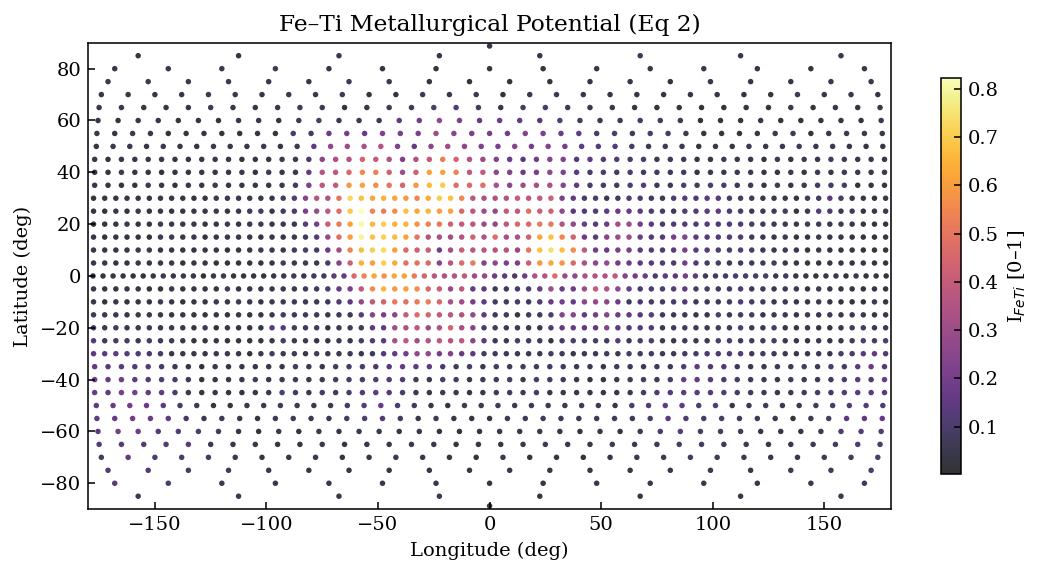

In [ ]:
# ============================================================
# Cell 12: Fig 3 — Fe-Ti metallurgical potential map
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.2))
sc = ax.scatter(df['lon'], df['lat'], c=df['I_FeTi'], s=8,
                cmap='inferno', alpha=0.8, edgecolors='none')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Fe\u2013Ti Metallurgical Potential (Eq 2)')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('I$_{FeTi}$ [0\u20131]')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/map_feti_index.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/map_feti_index.pdf', bbox_inches='tight')
log.info('Fig 3 saved: map_feti_index')
plt.show()

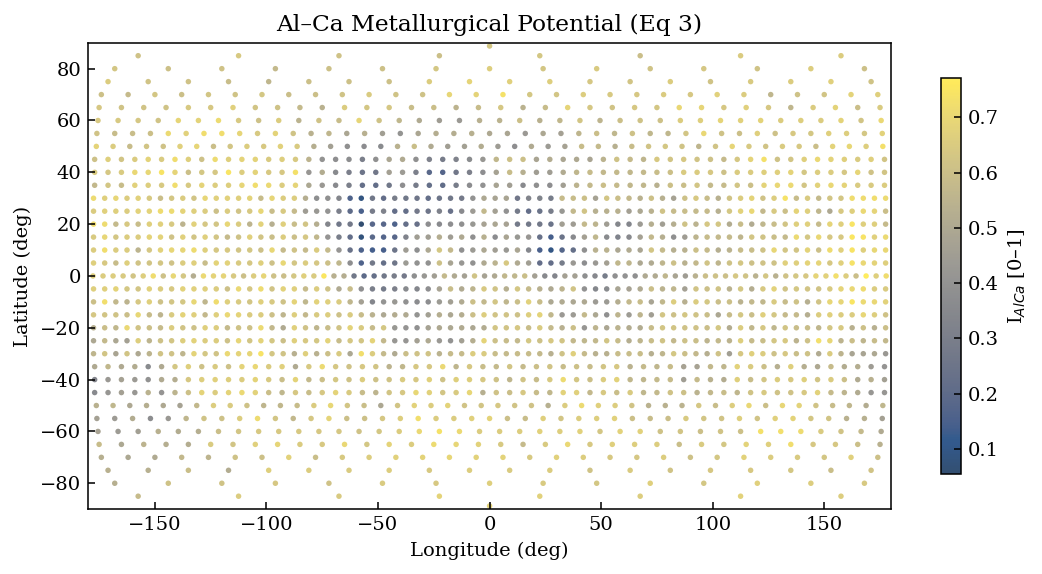

In [ ]:
# ============================================================
# Cell 13: Fig 4 — Al-Ca metallurgical potential map
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.2))
sc = ax.scatter(df['lon'], df['lat'], c=df['I_AlCa'], s=8,
                cmap='cividis', alpha=0.8, edgecolors='none')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Al\u2013Ca Metallurgical Potential (Eq 3)')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('I$_{AlCa}$ [0\u20131]')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/map_alca_index.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/map_alca_index.pdf', bbox_inches='tight')
log.info('Fig 4 saved: map_alca_index')
plt.show()

In [ ]:
# ============================================================
# Cell 14: Fig 5 — KREEP functional potential map
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.2))
sc = ax.scatter(df['lon'], df['lat'], c=df['I_KREEP'], s=8,
                cmap='magma', alpha=0.8, edgecolors='none')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('KREEP Functional Potential (Eq 4)')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('I$_{KREEP}$ [0\u20131]')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/map_kreep_index.png', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/map_kreep_index.pdf', bbox_inches='tight')
log.info('Fig 5 saved: map_kreep_index')
plt.show()

---
## Compatibility Matrix + Portfolio Assignment (Sec 3.5, Table 1, Eq 5)

In [ ]:
# ============================================================
# Cell 15: Table 1 — Compatibility matrix
# ============================================================
compat = pd.DataFrame([
    {'Terrane': 'Mare', 'Chemistry': 'Fe/Ti-rich',
     'Alloy family': 'Ni-superalloy / RHEA',
     'Likely process': 'DED + hybrid finishing',
     'Main risks': 'O pickup, feed variability',
     'Evidence class': 'Model-derived + Measured (Earth-side)'},
    {'Terrane': 'Highlands', 'Chemistry': 'Al/Ca-rich',
     'Alloy family': 'HEA / Ni-superalloy',
     'Likely process': 'PM + SLM/DED',
     'Main risks': 'Crack/oxidation balance',
     'Evidence class': 'Model-derived'},
    {'Terrane': 'KREEP-bearing', 'Chemistry': 'K/REE/P proxies',
     'Alloy family': 'HEA / functional RHEA layers',
     'Likely process': 'Graded/coating routes',
     'Main risks': 'Heterogeneity, beneficiation',
     'Evidence class': 'Assumed + Roadmap hypothesis'},
])

compat.to_csv(f'{TBL_DIR}/compatibility_matrix.csv', index=False)
log.info('Table 1 saved')
compat

,Terrane,Chemistry,Alloy family,Likely process,Main risks,Evidence class
0,Mare,Fe/Ti-rich,Ni-superalloy / RHEA,DED + hybrid finishing,"O pickup, feed variability",Model-derived + Measured (Earth-side)
1,Highlands,Al/Ca-rich,HEA / Ni-superalloy,PM + SLM/DED,Crack/oxidation balance,Model-derived
2,KREEP-bearing,K/REE/P proxies,HEA / functional RHEA layers,Graded/coating routes,"Heterogeneity, beneficiation",Assumed + Roadmap hypothesis


In [ ]:
# ============================================================
# Cell 16: Portfolio assignment (Eq 5)
# F(x_t, q_f, d_c) -> (a_f, b_w, p_r, c_l)
# ============================================================
alloy_map = {
    'mare': 'Ni-superalloy / RHEA',
    'highlands': 'HEA / Ni-superalloy',
    'kreep': 'HEA / functional RHEA layers',
}
process_map = {
    'mare': 'DED + hybrid',
    'highlands': 'PM + SLM/DED',
    'kreep': 'Graded/coating',
}
blend_map = {  # ISRU fraction estimate (heuristic)
    'mare': 0.7,       # Fe-Ti abundant, high ISRU potential
    'highlands': 0.5,  # Al moderate, needs beneficiation
    'kreep': 0.3,      # needs imported refractory bases
}
conf_map = {
    'mare': 'medium',
    'highlands': 'medium',
    'kreep': 'low',
}

df['alloy_family'] = df['terrane'].map(alloy_map)
df['process_route'] = df['terrane'].map(process_map)
df['blend_window'] = df['terrane'].map(blend_map)
df['confidence'] = df['terrane'].map(conf_map)

log.info('Portfolio assignment done')
df[['terrane', 'alloy_family', 'process_route', 'blend_window', 'confidence']].drop_duplicates()

,terrane,alloy_family,process_route,blend_window,confidence
0,highlands,HEA / Ni-superalloy,PM + SLM/DED,0.5,medium
9,mare,Ni-superalloy / RHEA,DED + hybrid,0.7,medium
526,kreep,HEA / functional RHEA layers,Graded/coating,0.3,low


---
## Export All Artifacts

In [ ]:
# ============================================================
# Cell 17: LaTeX table export
# ============================================================
latex_compat = compat.to_latex(index=False, escape=True,
                               column_format='llllll')  # 6 columns
with open(f'{TBL_DIR}/compatibility_matrix.tex', 'w') as f:
    f.write(latex_compat)

# Also export index summary as LaTeX
latex_idx = idx_summary.to_latex(escape=True, float_format='%.3f')
with open(f'{TBL_DIR}/indices_summary.tex', 'w') as f:
    f.write(latex_idx)

log.info('LaTeX tables saved')
print('--- Compatibility matrix (LaTeX) ---')
print(latex_compat)

--- Compatibility matrix (LaTeX) ---
\begin{tabular}{llllll}
\toprule
Terrane & Chemistry & Alloy family & Likely process & Main risks & Evidence class \\
\midrule
Mare & Fe/Ti-rich & Ni-superalloy / RHEA & DED + hybrid finishing & O pickup, feed variability & Model-derived + Measured (Earth-side) \\
Highlands & Al/Ca-rich & HEA / Ni-superalloy & PM + SLM/DED & Crack/oxidation balance & Model-derived \\
KREEP-bearing & K/REE/P proxies & HEA / functional RHEA layers & Graded/coating routes & Heterogeneity, beneficiation & Assumed + Roadmap hypothesis \\
\bottomrule
\end{tabular}



In [ ]:
# ============================================================
# Cell 18: Export full processed CSV + finalize manifest
# ============================================================
# Full export
export_cols = (['lat', 'lon', 'terrane'] + all_chem_cols +
               ['PC1', 'PC2', 'PC3', 'I_FeTi', 'I_AlCa', 'I_KREEP',
                'alloy_family', 'process_route', 'blend_window', 'confidence'])
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv(f'{TBL_DIR}/processed_full.csv', index=False)

# Terrane-level summary
terrane_summary = df.groupby('terrane')[['I_FeTi', 'I_AlCa', 'I_KREEP']].agg(['mean', 'std'])
terrane_summary.to_csv(f'{TBL_DIR}/terrane_index_summary.csv')

# Finalize manifest
manifest['outputs'] = sorted([
    os.path.join(dp, f)
    for dp, _, fns in os.walk(OUT_DIR)
    for f in fns
])
manifest['separability'] = separability
manifest['explained_variance'] = exp_var.tolist()
manifest['is_synthetic'] = USE_SYNTHETIC
manifest['clr_scope'] = {
    'clr_applied_to': oxide_cols,
    'z_scored_for_pca': trace_cols_pca,
    'excluded_from_pca': ['U (tied to Th, redundant)'],
    'rationale': 'CLR for compositional oxides (wt%); z-score for K,Th (ppm); U excluded (U=0.27*Th)',
}
manifest['preprocessing'] = {
    'oxide_zeros_replaced': oxide_zeros_replaced,
    'zero_replacement_method': 'terrane-wise median',
    'bootstrap_sign_correction': True,
}

# Fix for JSON serialization of numpy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

with open(f'{OUT_DIR}/manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, cls=NumpyEncoder)

log.info('All exports complete')
print('\n=== OUTPUT MANIFEST ===')
print(json.dumps(manifest, indent=2, cls=NumpyEncoder))
print('\n=== FILES ===')
for p in manifest['outputs']:
    print(f'  {p}')


=== OUTPUT MANIFEST ===
{
  "timestamp_utc": "2026-02-15T15:19:41.166301+00:00",
  "input_file": "lunar_geochem.csv",
  "input_sha256": "5ddc51f8da7a9c85fc7d8b1b41171ccf740b3aebf0e9a91e8787e66c71c59fd9",
  "is_synthetic": false,
  "n_rows": 1790,
  "packages": {
    "numpy": "2.0.2",
    "pandas": "2.2.2"
  },
  "outputs": [
    "outputs/figures/map_alca_index.pdf",
    "outputs/figures/map_alca_index.png",
    "outputs/figures/map_feti_index.pdf",
    "outputs/figures/map_feti_index.png",
    "outputs/figures/pca_biplot.pdf",
    "outputs/figures/pca_biplot.png",
    "outputs/figures/pca_loadings.pdf",
    "outputs/figures/pca_loadings.png",
    "outputs/manifest.json",
    "outputs/tables/compatibility_matrix.csv",
    "outputs/tables/compatibility_matrix.tex",
    "outputs/tables/indices_summary.csv",
    "outputs/tables/indices_summary.tex",
    "outputs/tables/pca_loadings.csv",
    "outputs/tables/pca_variance.csv",
    "outputs/tables/processed_full.csv",
    "outputs/tables/te

In [ ]:
# ============================================================
# Cell 19: Summary dashboard
# ============================================================
print('=' * 60)
print('WAMS 2026 Paper #68 — Pipeline Summary')
print('=' * 60)
print(f'Data source:    {"SYNTHETIC" if USE_SYNTHETIC else DATA_PATH}')
print(f'Rows processed: {len(df)}')
print(f'Terranes:       {df["terrane"].value_counts().to_dict()}')
print(f'Oxides (CLR):   {oxide_cols}')
print(f'Traces (PCA):   {trace_cols_pca}')
print(f'Excluded (PCA): U (tied to Th, U=0.27*Th)')
print(f'PCA features:   {pca_features} ({len(pca_features)} total)')
print(f'PCA variance:   PC1={exp_var[0]:.3f}  PC2={exp_var[1]:.3f}  PC3={exp_var[2]:.3f}')
print(f'Silhouette:     {sil:.4f}')
print(f'Davies-Bouldin: {dbi:.4f}')
print(f'Oxide zeros:    {oxide_zeros_replaced} replaced (terrane median)')
print(f'\nIndex means by terrane:')
print(terrane_summary.to_string())
print(f'\nFigures: {len([f for f in os.listdir(FIG_DIR)])} files in {FIG_DIR}')
print(f'Tables:  {len([f for f in os.listdir(TBL_DIR)])} files in {TBL_DIR}')
if USE_SYNTHETIC:
    print('\n*** WARNING: All results based on SYNTHETIC data. ***')
    print('*** Replace with real LP-GRS data before publication. ***')

WAMS 2026 Paper #68 — Pipeline Summary
Data source:    data/lunar_geochem.csv
Rows processed: 1790
Terranes:       {'highlands': 1296, 'kreep': 253, 'mare': 241}
Oxides (CLR):   ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2']
Traces (PCA):   ['K', 'Th']
Excluded (PCA): U (tied to Th, U=0.27*Th)
PCA features:   ['FeO', 'TiO2', 'Al2O3', 'CaO', 'MgO', 'SiO2', 'K', 'Th'] (8 total)
PCA variance:   PC1=0.682  PC2=0.145  PC3=0.094
Silhouette:     0.3965
Davies-Bouldin: 0.9647
Oxide zeros:    80 replaced (terrane median)

Index means by terrane:
             I_FeTi              I_AlCa             I_KREEP          
               mean       std      mean       std      mean       std
terrane                                                              
highlands  0.060092  0.029393  0.626140  0.052024  0.046912  0.049373
kreep      0.374793  0.180192  0.421924  0.129249  0.475651  0.151365
mare       0.256583  0.144658  0.452083  0.115863  0.150305  0.071890

Figures: 8 files in outputs/figures
